In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Load Dataset
`dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [2]:
dataset = load_dataset("dair-ai/emotion")
dataset

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
train_text = dataset['train']['text']
train_label = dataset['train']['label']

test_text = dataset['test']['text']
test_label = dataset['test']['label']

In [4]:
label_names=dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

This dataset contains 6 emotion class

0 --> joy

1 --> love

2 --> anger

3 --> fear

4 --> surprise

In [5]:
#Label mapping
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

# EDA

In [6]:
df_train.isnull().sum()

,0
text,0
label,0


In [7]:
df_train['label'].value_counts(normalize=True)*100

,proportion
label,
joy,33.51250
sadness,29.16250
anger,13.49375
fear,12.10625
love,8.15000
surprise,3.57500


<Axes: xlabel='label', ylabel='count'>

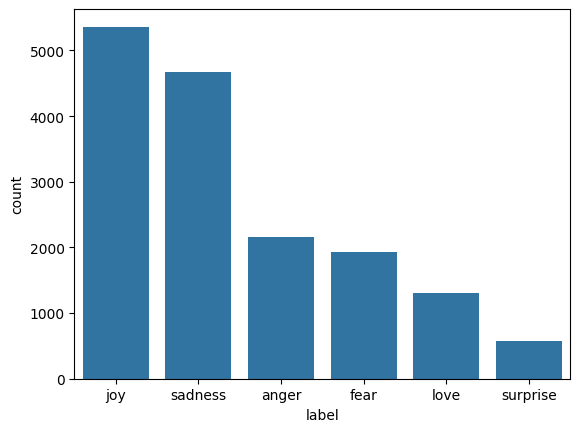

In [8]:
sns.countplot(x='label', data=df_train,order=df_train['label'].value_counts().index)

There is a class imbalance, we will fix through class weights

# Data Preprocessign - Using NLP

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import  pad_sequences
max_words = 100000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

max_len = max(len(seq) for seq in train_sequence)  #66

padded_train_sequence = pad_sequences(train_sequence, maxlen=max_len, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=max_len, padding='post', truncating='post')

train_labels = np.array(df_train['label'])
test_labels = np.array(df_test['label'])

num_classes = len(label_names)
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {max_len}")

Vocabulary Size: 15213
Max Sentence Length: 66


# Training Utilities

In [10]:
# compute class weights to handle dataset imbalance

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',        #n_samples / (n_classes * np.bincount(y)).
    classes= np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(1.2351397251814111),
 1: np.float64(1.3766993632765445),
 2: np.float64(0.49732686808404825),
 3: np.float64(2.044989775051125),
 4: np.float64(0.5715102157451064),
 5: np.float64(4.662004662004662)}

In [11]:
# Early stopping to save compute power if stabilization reached
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

# Foundational Models

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

In [13]:
import tensorflow
tensorflow.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

### M1: Simple RNN

input --> embedding(256) --> RNN

In [14]:
rnn = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 66),
    SimpleRNN(units = 128, return_sequences = True),
    Dropout(0.5),  #50% dropped randomly to tackle overfitting
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units=num_classes, activation = 'softmax')
])
rnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
# Map string labels to integer indices for sparse categorical crossentropy
label_to_index = {name: idx for idx, name in enumerate(label_names)}
train_labels_encoded = np.array([label_to_index[label] for label in train_labels])
test_labels_encoded = np.array([label_to_index[label] for label in test_labels])

rnn.fit(
    padded_train_sequence,
    train_labels_encoded,
    validation_data=(padded_test_sequence, test_labels_encoded),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn.evaluate(padded_test_sequence, test_labels_encoded)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.2882 - loss: 2.3051 - val_accuracy: 0.3475 - val_loss: 1.6687
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3180 - loss: 2.1730 - val_accuracy: 0.3445 - val_loss: 1.6670
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.3311 - loss: 2.1465 - val_accuracy: 0.3500 - val_loss: 1.6825
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.3294 - loss: 2.1406 - val_accuracy: 0.3475 - val_loss: 1.6979
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3333 - loss: 2.1367 - val_accuracy: 0.3470 - val_loss: 1.6746
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3445 - loss: 1.6670
RNN Loss: 1.667044997215271
RNN Accuracy: 0.34450000524520874


### 6.2 Standard LSTM

In [16]:
from tqdm.keras import TqdmCallback

lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 66),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Using the encoded integer labels to prevent the TypeError
lstm_model.fit(
    padded_train_sequence,
    train_labels_encoded,
    validation_data=(padded_test_sequence, test_labels_encoded),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, TqdmCallback(verbose=1)]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels_encoded)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.3191 - loss: 2.1669 - val_accuracy: 0.3475 - val_loss: 1.6502
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3334 - loss: 2.1473 - val_accuracy: 0.3475 - val_loss: 1.6909
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3338 - loss: 2.1419 - val_accuracy: 0.3475 - val_loss: 1.6576
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3358 - loss: 2.1361 - val_accuracy: 0.3475 - val_loss: 1.6686
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3475 - loss: 1.6502
LSTM Loss: 1.6501537561416626
LSTM Accuracy: 0.3474999964237213


### M3: Standard GRU

In [17]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 66),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Map string labels to integer indices for sparse categorical crossentropy
label_to_index = {name: idx for idx, name in enumerate(label_names)}
train_labels_encoded = np.array([label_to_index[label] for label in train_labels])
test_labels_encoded = np.array([label_to_index[label] for label in test_labels])

gru_model.fit(
    padded_train_sequence,
    train_labels_encoded,
    validation_data=(padded_test_sequence, test_labels_encoded),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, TqdmCallback(verbose=1)]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels_encoded)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3188 - loss: 2.1687 - val_accuracy: 0.3475 - val_loss: 1.6764
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3327 - loss: 2.1443 - val_accuracy: 0.3475 - val_loss: 1.6850
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3318 - loss: 2.1426 - val_accuracy: 0.3475 - val_loss: 1.6629
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3475 - loss: 1.6764
GRU Loss: 1.6764277219772339
GRU Accuracy: 0.3474999964237213


## Compare Them

In [18]:
result_df = pd.DataFrame({
    "Model" : ['RNN', 'LSTM', 'GRU'],
    "Test Loss": [rnn_loss, lstm_loss, gru_loss],
    "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by="Test Accuracy", ascending=False)

result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.650154,0.3475
2,GRU,1.676428,0.3475
0,RNN,1.667045,0.3445


# Advanced Bidirectional GRU

In [19]:
# 300D embeddings, 0.5 dropout
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 66),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer="adam",loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tqdm.keras import TqdmCallback

BiGRU.fit(
    padded_train_sequence,
    train_labels_encoded,
    validation_data=(padded_test_sequence, test_labels_encoded),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, TqdmCallback(verbose=1)]
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.6339 - loss: 1.1530 - val_accuracy: 0.8625 - val_loss: 0.4289
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9093 - loss: 0.2589 - val_accuracy: 0.9215 - val_loss: 0.2625
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9519 - loss: 0.1332 - val_accuracy: 0.9180 - val_loss: 0.2428
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9640 - loss: 0.0967 - val_accuracy: 0.9230 - val_loss: 0.2650
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9714 - loss: 0.0795 - val_accuracy: 0.9155 - val_loss: 0.2823
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9756 - loss: 0.0749 - val_accuracy: 0.9185 - val_loss: 0.2877


In [21]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels_encoded)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9180 - loss: 0.2428
BiGRU Loss: 0.24280980229377747
BiGRU Accuracy: 0.9179999828338623


In [22]:
result_df = pd.DataFrame({
    "Model" : ['RNN', 'LSTM', 'GRU', "BiGRU"],
    "Test Loss": [rnn_loss, lstm_loss, gru_loss, BiGRU_loss],
    "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy, BiGRU_accuracy]
}).sort_values(by="Test Accuracy", ascending=False)

result_df

,Model,Test Loss,Test Accuracy
3,BiGRU,0.242810,0.9180
1,LSTM,1.650154,0.3475
2,GRU,1.676428,0.3475
0,RNN,1.667045,0.3445


# Overall Evaluation

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


<Axes: >

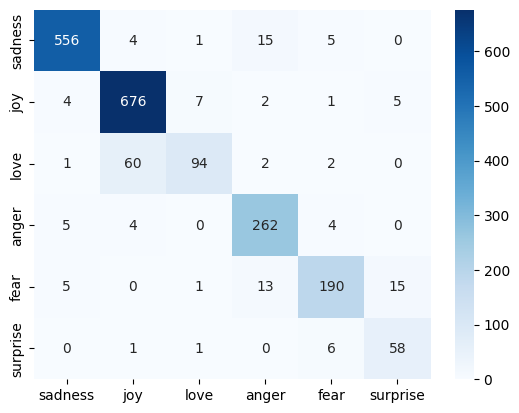

In [23]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

# Sample Test

In [24]:
sample_texts = [
    "I woke up feeling incredibly optimistic about what the future has in store for me.",
    "Even though everything seems to be going wrong lately, I can't shake this overwhelming sense of emptiness.",
    "I was absolutely livid when I found out they had lied to me for months.",
    "The thought of having to confront him tomorrow fills me with an unsettling sense of dread.",
    "I couldn't believe my eyes when I opened the package and discovered what was inside.",

    "After months of hard work, seeing my project finally succeed made me genuinely ecstatic.",
    "I keep pretending that I'm okay, but deep down I feel completely defeated and exhausted.",
    "I was so irritated by their constant interruptions that I eventually walked out of the meeting.",
    "My heart started racing when I realized I had accidentally taken the wrong train.",
    "The announcement caught everyone off guard, and I was left completely stunned.",

    "Getting accepted into the program was one of the most rewarding moments of my life.",
    "No matter how many people surround me, lately I have felt strangely disconnected from everyone.",
    "I am beyond frustrated that they ignored every warning and now expect me to fix their mistake.",
    "I felt an inexplicable sense of panic as the elevator suddenly stopped between floors.",
    "The sheer generosity of the stranger left me speechless.",

    "I was cautiously hopeful at first, but the results exceeded even my wildest expectations.",
    "I smiled and told everyone I was fine, although internally I was falling apart.",
    "I could feel my anger building every time they dismissed my concerns as insignificant.",
    "The uncertainty of what might happen next made me extremely uneasy.",
    "I was genuinely astonished to discover that the person I trusted most had kept this secret from me.",

    "Despite all the setbacks, I feel strangely content with where I am in life.",
    "I have been carrying this sadness for so long that I barely remember what being carefree feels like.",
    "I was outraged when they blamed me for something that was clearly their responsibility.",
    "The possibility of losing everything I had worked for left me paralyzed with fear.",
    "I was completely taken aback when my supposedly quiet colleague suddenly announced the news.",

    "For the first time in years, I feel like things are finally falling into place.",
    "I don't necessarily feel sad; I just feel numb, as though nothing matters anymore.",
    "I wasn't merely annoyed—I was genuinely offended by the way they spoke to me.",
    "I tried to remain calm, but every unexpected noise made me increasingly nervous.",
    "The outcome was so unexpected that I needed several minutes just to process what had happened."
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
Text: I woke up feeling incredibly optimistic about what the future has in store for me.
Predicted Emotion: joy
Text: Even though everything seems to be going wrong lately, I can't shake this overwhelming sense of emptiness.
Predicted Emotion: joy
Text: I was absolutely livid when I found out they had lied to me for months.
Predicted Emotion: anger
Text: The thought of having to confront him tomorrow fills me with an unsettling sense of dread.
Predicted Emotion: joy
Text: I couldn't believe my eyes when I opened the package and discovered what was inside.
Predicted Emotion: fear
Text: After months of hard work, seeing my project finally succeed made me genuinely ecstatic.
Predicted Emotion: joy
Text: I keep pretending that I'm okay, but deep down I feel completely defeated and exhausted.
Predicted Emotion: sadness
Text: I was so irritated by their constant interruptions that I eventually walked out of the meeting.
Predicted Emotion: anger
Text: My

# Save Model and Tokenizer

In [25]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)

# Download them

In [26]:
from google.colab import files

files.download('Artifacts/BiGRU_Modle.keras')
files.download('Artifacts/tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>